In [10]:
import pandas as pd
from pyfaidx import Fasta
from Bio import SeqIO
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from Bio.Seq import Seq

In [11]:
lnc_location_df = pd.read_csv("/lulabdata3/huangkeyun/zhangys/RNA_locator/resources/RNAlocate/lncRNA_location_resources.csv")
lnc_location_df

,RNA Symbol,RNA Category,Species,Tissue/Cell Line,Localization,Score
0,TPRG1-AS1,lncRNA,Homo sapiens,human aortic smooth muscle cells,Cytoplasm,0.694506
1,GAS5,lncRNA,Homo sapiens,human embryonic kidney cell line HEK293T,Mitochondrion,0.890460
2,NORAD,lncRNA,Homo sapiens,human embryonic kidney cell line HEK293T,Mitochondrion,0.795006
3,KB-1460A1.5,lncRNA,Homo sapiens,human embryonic kidney cell line HEK293T,Mitochondrion,0.694506
4,SYNE3,lncRNA,Homo sapiens,human embryonic kidney cell line HEK293T,Mitochondrion,0.694506
...,...,...,...,...,...,...
24956,ZFY-AS1,lncRNA,Homo sapiens,HCC cell line (HepG2),Nucleus,0.396359
24957,ST20-AS1,lncRNA,Homo sapiens,HeLa-S3 cells,Nucleus,0.396359
24958,GNAS-AS1,lncRNA,Homo sapiens,HeLa-S3 cells,Nucleus,0.396359
24959,LINC00467,lncRNA,Homo sapiens,HEK293T cell line,Ribosome,0.795006


In [12]:
# 1. 提取 FASTA 文件中的序列并存入字典 (仅保留遇到的第一个 RNA Symbol对应的序列)
fasta_file = "/lulabdata3/huangkeyun/zhangys/RNA_locator/resources/ensenble/lncRNA.fasta"
fasta_dict = {}

with open(fasta_file, "r") as f:
    current_symbol = None
    current_seq = []
    
    for line in f:
        line = line.strip()
        if line.startswith(">"):
            # 保存上一个序列
            if current_symbol and current_symbol not in fasta_dict:
                fasta_dict[current_symbol] = "".join(current_seq)
            
            # 以空格分割，遍历寻找 'gene_symbol:' 字段，这样更健壮
            current_symbol = None
            parts = line.split(" ")
            for part in parts:
                if part.startswith("gene_symbol:"):
                    current_symbol = part.split("gene_symbol:")[1]
                    break
            
            current_seq = []
        else:
            if current_symbol is not None:
                current_seq.append(line)
            
    # 保存最后一个序列
    if current_symbol and current_symbol not in fasta_dict:
        fasta_dict[current_symbol] = "".join(current_seq)

# 2. 将序列映射到 lnc_location_df 的 Sequence 列
# 假设你的 DataFrame 中包含 'RNA Symbol' 这一列，如果不叫这个名字请根据实际情况替换列名
lnc_location_df['Sequence'] = lnc_location_df['RNA Symbol'].map(fasta_dict)

lnc_location_df

,RNA Symbol,RNA Category,Species,Tissue/Cell Line,Localization,Score,Sequence
0,TPRG1-AS1,lncRNA,Homo sapiens,human aortic smooth muscle cells,Cytoplasm,0.694506,AGACAGTGGGGGTGGGGAGGAGGCTGCAGGAGGCTCCTGGCTGGGA...
1,GAS5,lncRNA,Homo sapiens,human embryonic kidney cell line HEK293T,Mitochondrion,0.890460,AGGTATGGTGCTGGGTGCAGATGCAGTGTGGCTCTGGATAGCACCT...
2,NORAD,lncRNA,Homo sapiens,human embryonic kidney cell line HEK293T,Mitochondrion,0.795006,AGCGCAAGGGCACTTCCGGTACCGCTCCTCTCTTGCCAGCGCAGAG...
3,KB-1460A1.5,lncRNA,Homo sapiens,human embryonic kidney cell line HEK293T,Mitochondrion,0.694506,NaN
4,SYNE3,lncRNA,Homo sapiens,human embryonic kidney cell line HEK293T,Mitochondrion,0.694506,NaN
...,...,...,...,...,...,...,...
24956,ZFY-AS1,lncRNA,Homo sapiens,HCC cell line (HepG2),Nucleus,0.396359,GGGGAAAGCAAGCTTACAGAAGCAGAACAAACGCAGTTAAACTGTG...
24957,ST20-AS1,lncRNA,Homo sapiens,HeLa-S3 cells,Nucleus,0.396359,AAAATGCCCAGACCAGCATCCGAAAGCTGGTCTCCTATACAAAGCA...
24958,GNAS-AS1,lncRNA,Homo sapiens,HeLa-S3 cells,Nucleus,0.396359,GTTGGAACGCCCGAAGAGGTGCTGCTGGGGTGGTTGGAAGCCGGTG...
24959,LINC00467,lncRNA,Homo sapiens,HEK293T cell line,Ribosome,0.795006,TCCGCTCCCGCCCCGCTCTGTGGCGTAGGCCGGACATTTCTAGTCG...


In [13]:
# 3. 去除 Sequence 为空或包含 'N' 的行
# 去除空值 (NaN)
lnc_location_df = lnc_location_df.dropna(subset=['Sequence'])
# 过滤掉 Sequence 包含大写 'N' 或小写 'n' 的行，并重置索引
lnc_location_df = lnc_location_df[~lnc_location_df['Sequence'].str.contains('N|n')].reset_index(drop=True)

lnc_location_df

,RNA Symbol,RNA Category,Species,Tissue/Cell Line,Localization,Score,Sequence
0,TPRG1-AS1,lncRNA,Homo sapiens,human aortic smooth muscle cells,Cytoplasm,0.694506,AGACAGTGGGGGTGGGGAGGAGGCTGCAGGAGGCTCCTGGCTGGGA...
1,GAS5,lncRNA,Homo sapiens,human embryonic kidney cell line HEK293T,Mitochondrion,0.890460,AGGTATGGTGCTGGGTGCAGATGCAGTGTGGCTCTGGATAGCACCT...
2,NORAD,lncRNA,Homo sapiens,human embryonic kidney cell line HEK293T,Mitochondrion,0.795006,AGCGCAAGGGCACTTCCGGTACCGCTCCTCTCTTGCCAGCGCAGAG...
3,LINC00648,lncRNA,Homo sapiens,human embryonic kidney cell line HEK293T,Mitochondrion,0.795006,GCCCGTTCTCAGATCTCCAGCTGCGTGCTGGGAGAACCACTGCTCC...
4,LINC00205,lncRNA,Homo sapiens,human embryonic kidney cell line HEK293T,Mitochondrion,0.795006,GCATGCGTTATGCGCCATCACCGGCAAGCAGGGGCGGGAGGGGGAA...
...,...,...,...,...,...,...,...
22875,ZFY-AS1,lncRNA,Homo sapiens,HCC cell line (HepG2),Nucleus,0.396359,GGGGAAAGCAAGCTTACAGAAGCAGAACAAACGCAGTTAAACTGTG...
22876,ST20-AS1,lncRNA,Homo sapiens,HeLa-S3 cells,Nucleus,0.396359,AAAATGCCCAGACCAGCATCCGAAAGCTGGTCTCCTATACAAAGCA...
22877,GNAS-AS1,lncRNA,Homo sapiens,HeLa-S3 cells,Nucleus,0.396359,GTTGGAACGCCCGAAGAGGTGCTGCTGGGGTGGTTGGAAGCCGGTG...
22878,LINC00467,lncRNA,Homo sapiens,HEK293T cell line,Ribosome,0.795006,TCCGCTCCCGCCCCGCTCTGTGGCGTAGGCCGGACATTTCTAGTCG...


lnc_location_df 清洗完成：删除了 66 条过长序列，剩余 22814 条。

--- lnc_location_df 长度统计 ---
最短序列长度: 88
最长序列长度: 10468
平均序列长度: 1628.01


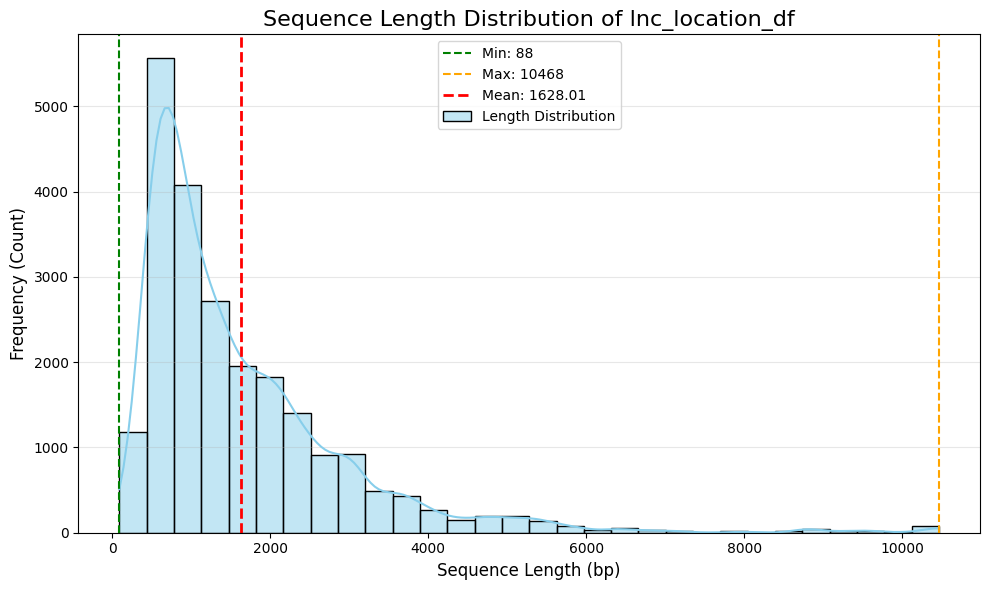

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# 长度清晰
lnc_location_df['Sequence_Length'] = lnc_location_df['Sequence'].str.len()
original_m_count = len(lnc_location_df)

# 执行长度过滤（保留 <= 11238 bp 的行，具体阈值可根据需要调整）
lnc_location_df = lnc_location_df[lnc_location_df['Sequence_Length'] <= 11238].copy()

# 统计并打印结果
deleted_m = original_m_count - len(lnc_location_df)
print(f"lnc_location_df 清洗完成：删除了 {deleted_m} 条过长序列，剩余 {len(lnc_location_df)} 条。\n")

# 计算序列长度
lnc_location_df['Sequence_Length'] = lnc_location_df['Sequence'].str.len()

# 1. 基础统计量计算
max_length = lnc_location_df['Sequence_Length'].max()
min_length = lnc_location_df['Sequence_Length'].min()
average_length = lnc_location_df['Sequence_Length'].mean()

print(f"--- lnc_location_df 长度统计 ---")
print(f"最短序列长度: {min_length}")
print(f"最长序列长度: {max_length}")
print(f"平均序列长度: {average_length:.2f}")

# 2. 设置分箱区间并打印分布详情
bins = np.histogram_bin_edges(lnc_location_df['Sequence_Length'], bins=30)
bin_counts, bin_edges = np.histogram(lnc_location_df['Sequence_Length'], bins=bins)


# 3. 绘制分布图
plt.figure(figsize=(10, 6))
sns.histplot(lnc_location_df['Sequence_Length'], bins=bins, kde=True, color='skyblue', label='Length Distribution')

# 4. 添加最小值、最大值和平均值的垂直标注线
plt.axvline(min_length, color='green', linestyle='--', linewidth=1.5, label=f'Min: {min_length}')
plt.axvline(max_length, color='orange', linestyle='--', linewidth=1.5, label=f'Max: {max_length}')
plt.axvline(average_length, color='red', linestyle='--', linewidth=2, label=f'Mean: {average_length:.2f}')

# 5. 图形细节美化
plt.title('Sequence Length Distribution of lnc_location_df', fontsize=16)
plt.xlabel('Sequence Length (bp)', fontsize=12)
plt.ylabel('Frequency (Count)', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# 6. 展示图形
plt.show()

In [15]:
lnc_location_df['Localization'].value_counts()

Localization
Extracellular exosome    12433
Nucleus                   5133
Cytosol                   3674
Cytoplasm                 1009
Extracellular vesicle      520
Mitochondrion               24
Nucleoplasm                 15
Ribosome                     4
Nucleolus                    2
Name: count, dtype: int64

In [16]:
# 根据 Localization 列的内容生成 tag 列
lnc_location_df['tag'] = lnc_location_df['Localization'].isin(['Extracellular exosome', 'Extracellular vesicle']).astype(int)

# 查看 tag 列的结果分布
lnc_location_df['tag'].value_counts()

tag
1    12953
0     9861
Name: count, dtype: int64

In [17]:
print("平衡前的标签分布:")
print(lnc_location_df['tag'].value_counts())

# 获取少数类的样本数量
min_count = lnc_location_df['tag'].value_counts().min()

# 按 tag 分组，并随机抽取与少数类相同数量的样本 (设置 random_state 保证结果可复现)
lnc_location_df = lnc_location_df.groupby('tag').sample(n=min_count, random_state=42).reset_index(drop=True)

# 查看平衡后的结果分布
print("\n平衡后的标签分布:")
print(lnc_location_df['tag'].value_counts())

平衡前的标签分布:
tag
1    12953
0     9861
Name: count, dtype: int64

平衡后的标签分布:
tag
0    9861
1    9861
Name: count, dtype: int64


In [18]:
# 4. 将 DataFrame 保存为 FASTA 文件
output_fasta = "./linearDataSet/lncRNA_balanced_dataset.fa"

with open(output_fasta, "w") as f:
    for index, row in lnc_location_df.iterrows():
        # 拼接 RNA Symbol 和 tag 作为标题
        header = f">{row['RNA Symbol']}_{row['tag']}"
        sequence = row['Sequence']
        f.write(f"{header}\n{sequence}\n")